# Climate Change & Food Security: Hybrid TCN-MLP Model for Nigerian Crop Yields
**Version 4.2: Hybrid Enhanced Dataset with Annual Targets + Monthly Features**

This notebook trains a TCN-MLP hybrid deep learning model on the enhanced hybrid dataset combining annual yield targets with 12-month climate and soil features.

**Data Source**: `annual_yield_hybrid_enhanced.csv` (288 samples, 221 features)
**Model Architecture**: TCN branch + MLP branch with Region/Crop embeddings
**Target Period**: Years 2000-2023 | Crops: Cassava, Yams | Regions: 6 geopolitical zones

---
## SECTION 1: Load and Validate Enhanced Dataset

In [1]:
# ─── SETUP & IMPORTS ────────────────────────────────────────────────────────
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv1D, Dropout, BatchNormalization, Activation, Add, GlobalAveragePooling1D, Dense, Concatenate, Flatten, Embedding

print(f"✓ Environment Setup Complete")
print(f"  TensorFlow version: {tf.__version__}")
print(f"  Python version: {sys.version.split()[0]}")

# ─── CONFIGURATION ──────────────────────────────────────────────────────────
os.chdir('c:\\Users\\ibito\\Documents\\Final_Year_Project')
ZONES = ['North Central', 'North East', 'North West', 'South East', 'South South', 'South West']
CROPS = ['Cassava', 'Yams']

print(f"\n✓ Configuration:")
print(f"  Regions (ZONES): {ZONES}")
print(f"  Crops: {CROPS}")
print(f"  Working directory: {os.getcwd()}")

✓ Environment Setup Complete
  TensorFlow version: 2.20.0
  Python version: 3.13.5

✓ Configuration:
  Regions (ZONES): ['North Central', 'North East', 'North West', 'South East', 'South South', 'South West']
  Crops: ['Cassava', 'Yams']
  Working directory: c:\Users\ibito\Documents\Final_Year_Project


In [2]:
# ─── LOAD HYBRID ENHANCED DATASET ────────────────────────────────────────────
print("\nLoading hybrid enhanced dataset...\n")

df_raw = pd.read_csv('project_data/processed_data/annual_yield_hybrid_enhanced.csv')

print(f"✓ Dataset loaded: {df_raw.shape}")
print(f"\n📊 Dataset Overview:")
print(f"  Rows: {df_raw.shape[0]} samples")
print(f"  Columns: {df_raw.shape[1]}")
print(f"  Memory: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nColumn Names (first 20):")
for i, col in enumerate(df_raw.columns[:20]):
    print(f"  {i+1}. {col}")
print(f"  ... ({df_raw.shape[1] - 20} more columns)")

print(f"\nMissing Values:")
missing = df_raw.isnull().sum()
if missing.sum() == 0:
    print(f"  ✓ No missing values!")
else:
    print(f"  ⚠ {missing[missing > 0].to_dict()}")

print(f"\nData Types:")
print(f"  {df_raw.dtypes.value_counts().to_dict()}")

print(f"\nFirst 5 rows:")
print(df_raw.head())


Loading hybrid enhanced dataset...

✓ Dataset loaded: (288, 221)

📊 Dataset Overview:
  Rows: 288 samples
  Columns: 221
  Memory: 0.53 MB

Column Names (first 20):
  1. Region
  2. Crop
  3. Year
  4. Yield_kg_per_ha
  5. seq_months
  6. Temperature_C_m1
  7. Rainfall_mm_m1
  8. Humidity_percent_m1
  9. Soil_Moisture_m3m3_m1
  10. GDD_m1
  11. Cumulative_Rainfall_m1
  12. Heat_Stress_m1
  13. Cold_Stress_m1
  14. Drought_Risk_m1
  15. Flood_Risk_m1
  16. Temp_Anomaly_m1
  17. Rainfall_Anomaly_m1
  18. Soil_Anomaly_m1
  19. Is_Rainy_Season_m1
  20. Is_Peak_Growth_m1
  ... (201 more columns)

Missing Values:
  ✓ No missing values!

Data Types:
  {dtype('float64'): 217, dtype('O'): 3, dtype('int64'): 1}

First 5 rows:
          Region     Crop  Year  Yield_kg_per_ha  \
0  North Central  Cassava  2000      2120.835885   
1  North Central  Cassava  2001      2162.726008   
2  North Central  Cassava  2002      2244.175145   
3  North Central  Cassava  2003      2257.515013   
4  North Cent

In [3]:
# ─── DATA VALIDATION & STATISTICS ──────────────────────────────────────────
print("\n" + "="*70)
print("DATA STATISTICS")
print("="*70)

# Check key columns
key_cols = ['Region', 'Crop', 'Year', 'Yield_kg_per_ha']
print(f"\nKey Columns: {key_cols}")
print(f"  All present: {all(col in df_raw.columns for col in key_cols)}")

print(f"\n🌍 Regions:")
regions = df_raw['Region'].unique()
print(f"  Total: {len(regions)} | Values: {sorted(regions)}")
print(f"  Counts:\n{df_raw['Region'].value_counts()}")

print(f"\n🌾 Crops:")
crops = df_raw['Crop'].unique()
print(f"  Total: {len(crops)} | Values: {sorted(crops)}")
print(f"  Counts:\n{df_raw['Crop'].value_counts()}")

print(f"\n📅 Years:")
years = sorted(df_raw['Year'].unique())
print(f"  Range: {min(years)}-{max(years)} ({len(years)} years)")

print(f"\n🎯 Yield Statistics (kg/ha):")
yield_stats = df_raw['Yield_kg_per_ha'].describe()
print(f"  Min: {yield_stats['min']:.2f}")
print(f"  Max: {yield_stats['max']:.2f}")
print(f"  Mean: {yield_stats['mean']:.2f}")
print(f"  Std: {yield_stats['std']:.2f}")
print(f"  Quantiles: 25%={yield_stats['25%']:.2f}, 50%={yield_stats['50%']:.2f}, 75%={yield_stats['75%']:.2f}")

print(f"\n✓ Data validation complete!")


DATA STATISTICS

Key Columns: ['Region', 'Crop', 'Year', 'Yield_kg_per_ha']
  All present: True

🌍 Regions:
  Total: 6 | Values: ['North Central', 'North East', 'North West', 'South East', 'South South', 'South West']
  Counts:
Region
North Central    48
North East       48
North West       48
South East       48
South South      48
South West       48
Name: count, dtype: int64

🌾 Crops:
  Total: 2 | Values: ['Cassava', 'Yams']
  Counts:
Crop
Cassava    144
Yams       144
Name: count, dtype: int64

📅 Years:
  Range: 2000-2023 (24 years)

🎯 Yield Statistics (kg/ha):
  Min: 464.27
  Max: 3735.73
  Mean: 1689.42
  Std: 519.84
  Quantiles: 25%=1388.17, 50%=1688.67, 75%=2108.20

✓ Data validation complete!


## SECTION 2: Data Preprocessing and Temporal Splitting

In [5]:
# ─── RECONSTRUCT TEMPORAL SEQUENCES FROM FLATTENED FORMAT ──────────────────
print("\nReconstructing temporal sequences from flattened format...\n")

# Extract metadata columns
metadata_cols = ['Region', 'Crop', 'Year', 'Yield_kg_per_ha']
metadata_df = df_raw[metadata_cols].copy()

# Extract feature columns (all columns except metadata and seq_months)
feature_cols = [col for col in df_raw.columns if col not in metadata_cols and col != 'seq_months']
print(f"Total feature columns: {len(feature_cols)}")
print(f"Sample features: {feature_cols[:10]}")

# The features are stored as Feature_m1, Feature_m2, ..., Feature_m12
# We need to reshape them into X_seq of shape (n_samples, 12, n_unique_features)

# Extract unique feature names (without month suffix)
# Feature format: "Temperature_C_m1", "Rainfall_mm_m1", etc.
unique_features = set()
for col in feature_cols:
    if '_m' in col:
        # Extract feature name (everything before _m)
        feature_name = col.rsplit('_m', 1)[0]
        unique_features.add(feature_name)

unique_features = sorted(list(unique_features))
n_features = len(unique_features)
n_samples = df_raw.shape[0]
n_months = 12

print(f"\n✓ Temporal sequence structure:")
print(f"  Samples: {n_samples}")
print(f"  Months: {n_months}")
print(f"  Features per month: {n_features}")
print(f"  Unique features: {unique_features}")

# Reconstruct X_seq
X_seq = np.zeros((n_samples, n_months, n_features))

for month in range(1, n_months + 1):
    for feat_idx, feat_name in enumerate(unique_features):
        col_name = f'{feat_name}_m{month}'
        if col_name in df_raw.columns:
            X_seq[:, month-1, feat_idx] = df_raw[col_name].values

# Extract targets
y = df_raw['Yield_kg_per_ha'].values

print(f"\n✓ Sequences reconstructed:")
print(f"  X_seq shape: {X_seq.shape}")
print(f"  y shape: {y.shape}")
print(f"  X_seq sample stats (first row):")
print(f"    Mean: {X_seq[0].mean():.4f}, Std: {X_seq[0].std():.4f}, Min: {X_seq[0].min():.4f}, Max: {X_seq[0].max():.4f}")


Reconstructing temporal sequences from flattened format...

Total feature columns: 216
Sample features: ['Temperature_C_m1', 'Rainfall_mm_m1', 'Humidity_percent_m1', 'Soil_Moisture_m3m3_m1', 'GDD_m1', 'Cumulative_Rainfall_m1', 'Heat_Stress_m1', 'Cold_Stress_m1', 'Drought_Risk_m1', 'Flood_Risk_m1']

✓ Temporal sequence structure:
  Samples: 288
  Months: 12
  Features per month: 18
  Unique features: ['Cold_Stress', 'Cumulative_Rainfall', 'Drought_Risk', 'Flood_Risk', 'GDD', 'Heat_Stress', 'Humidity_percent', 'Is_Peak_Growth', 'Is_Rainy_Season', 'Rainfall_Anomaly', 'Rainfall_mm', 'SoilMoisture_Rain_Interaction', 'SoilMoisture_Temp_Interaction', 'Soil_Anomaly', 'Soil_Moisture_m3m3', 'Temp_Anomaly', 'Temp_Humidity_Interaction', 'Temperature_C']

✓ Sequences reconstructed:
  X_seq shape: (288, 12, 18)
  y shape: (288,)
  X_seq sample stats (first row):
    Mean: 406.1610, Std: 1580.8460, Min: -0.4563, Max: 12182.2000


In [40]:
# ─── CATEGORICAL ID MAPPINGS ────────────────────────────────────────────────
print("\nPreparing categorical ID mappings...\n")

# Create region and crop ID mappings
region_to_id = {region: idx for idx, region in enumerate(ZONES)}
crop_to_id = {crop: idx for idx, crop in enumerate(CROPS)}

print(f"Region mapping: {region_to_id}")
print(f"Crop mapping: {crop_to_id}")

# Extract region and crop IDs
region_ids = np.array([region_to_id.get(r, 0) for r in metadata_df['Region']], dtype=np.int32).reshape(-1, 1)
crop_ids = np.array([crop_to_id.get(c, 0) for c in metadata_df['Crop']], dtype=np.int32).reshape(-1, 1)

print(f"\nCategorical IDs:")
print(f"  region_ids shape: {region_ids.shape}")
print(f"  crop_ids shape: {crop_ids.shape}")

print(f"\n✓ Mappings Ready. Full dataset: {len(X_seq)} samples.")


Preparing categorical ID mappings...

Region mapping: {'North Central': 0, 'North East': 1, 'North West': 2, 'South East': 3, 'South South': 4, 'South West': 5}
Crop mapping: {'Cassava': 0, 'Yams': 1}

Categorical IDs:
  region_ids shape: (288, 1)
  crop_ids shape: (288, 1)

✓ Mappings Ready. Full dataset: 288 samples.


In [74]:
# ─── RANDOM STRATIFIED TRAIN / TEST SPLIT & LOG SCALING ───────────────────
print("\nApplying Random Train/Test Split, Log Transforms and StandardScaler...\n")
from sklearn.model_selection import train_test_split

# Because N=288 is extremely small for Deep Learning, a strict Chronological split leaves
# the out-of-time test set extremely vulnerable to single spatial anomalies (e.g. 2022 SE crash).
# We use a randomized train-test split (85/15) stratified by Crop to ensure robust metrics.
X_train_seq_raw, X_test_seq_raw, y_train_raw, y_test_raw, region_ids_train, region_ids_test, crop_ids_train, crop_ids_test, metadata_train_df, metadata_test_df = train_test_split(
    X_seq, y, region_ids, crop_ids, metadata_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=crop_ids
)

# Further split train into train and val (for early stopping)
X_train_seq_raw, X_val_seq_raw, y_train_raw, y_val_raw, region_ids_train, region_ids_val, crop_ids_train, crop_ids_val, metadata_train, metadata_val = train_test_split(
    X_train_seq_raw, y_train_raw, region_ids_train, crop_ids_train, metadata_train_df,
    test_size=0.15,
    random_state=42,
    stratify=crop_ids_train
)

metadata_test = metadata_test_df.reset_index(drop=True)
metadata_train = metadata_train.reset_index(drop=True)
metadata_val = metadata_val.reset_index(drop=True)

# ─── ADDING CLIMATE/TECH PROGRESSION FEATURES (YEAR) ────────────────────────
# The Year encodes climate change and technological advancement progression.
# Add polynomial features (year², year³) to capture non-linear climate drift.
year_scaler = StandardScaler()
year_train_raw = metadata_train[['Year']].values
year_val_raw = metadata_val[['Year']].values
year_test_raw = metadata_test[['Year']].values

# Fit scaler on training years only
year_scaler.fit(year_train_raw)
year_train = year_scaler.transform(year_train_raw)
year_val = year_scaler.transform(year_val_raw)
year_test = year_scaler.transform(year_test_raw)

# Create polynomial year features (year², year³)
year2_train = year_scaler.transform((year_train_raw ** 2) / (metadata_train['Year'].max() ** 2))
year2_val = year_scaler.transform((year_val_raw ** 2) / (metadata_val['Year'].max() ** 2))
year2_test = year_scaler.transform((year_test_raw ** 2) / (metadata_test['Year'].max() ** 2))

year3_train = year_scaler.transform((year_train_raw ** 3) / (metadata_train['Year'].max() ** 3))
year3_val = year_scaler.transform((year_val_raw ** 3) / (metadata_val['Year'].max() ** 3))
year3_test = year_scaler.transform((year_test_raw ** 3) / (metadata_test['Year'].max() ** 3))

# Stack polynomial features: [year, year², year³]
year_train = np.hstack([year_train, year2_train, year3_train])
year_val = np.hstack([year_val, year2_val, year3_val])
year_test = np.hstack([year_test, year2_test, year3_test])

# Apply Feature Transformations (Log on skewed features)
skewed_features = ['Cumulative_Rainfall_mm', 'Rainfall_mm', 'GDD']
X_train_seq_proc = X_train_seq_raw.copy()
X_val_seq_proc = X_val_seq_raw.copy()
X_test_seq_proc = X_test_seq_raw.copy()

for i, feat_name in enumerate(unique_features):
    if any(sf in feat_name for sf in skewed_features):
        X_train_seq_proc[:,:,i] = np.log1p(X_train_seq_raw[:,:,i])
        X_val_seq_proc[:,:,i] = np.log1p(X_val_seq_raw[:,:,i])
        X_test_seq_proc[:,:,i] = np.log1p(X_test_seq_raw[:,:,i])

# Global Scaler implementation (Fit on Train)
scaler_X = StandardScaler()
X_train_flat = X_train_seq_proc.reshape(-1, n_features)
X_train_s = scaler_X.fit_transform(X_train_flat).reshape(X_train_seq_raw.shape)

X_val_s = scaler_X.transform(X_val_seq_proc.reshape(-1, n_features)).reshape(X_val_seq_raw.shape)
X_test_s = scaler_X.transform(X_test_seq_proc.reshape(-1, n_features)).reshape(X_test_seq_raw.shape)

# Log transform the targets
scaler_y = StandardScaler()
y_train_log = np.log(y_train_raw)
y_val_log = np.log(y_val_raw)
y_test_log = np.log(y_test_raw)

y_train_s = scaler_y.fit_transform(y_train_log.reshape(-1, 1)).ravel()
y_val_s = scaler_y.transform(y_val_log.reshape(-1, 1)).ravel()
y_test_s = scaler_y.transform(y_test_log.reshape(-1, 1)).ravel()

y_train, y_val, y_test = y_train_raw, y_val_raw, y_test_raw
n_features_count = n_features

print(f"\n✓ TIME-BASED SPLIT (Random Stratified):")
print(f"  Train: {len(X_train_s):,} samples")
print(f"  Val:   {len(X_val_s):,} samples")
print(f"  Test:  {len(X_test_s):,} samples")
print(f"  Total: {len(X_seq):,} samples")
print(f"\n✓ YEAR POLYNOMIAL FEATURES:")
print(f"  year_train shape: {year_train.shape} (contains [year, year², year³])")


Applying Random Train/Test Split, Log Transforms and StandardScaler...


✓ TIME-BASED SPLIT (Random Stratified):
  Train: 207 samples
  Val:   37 samples
  Test:  44 samples
  Total: 288 samples

✓ YEAR POLYNOMIAL FEATURES:
  year_train shape: (207, 3) (contains [year, year², year³])


## SECTION 3: Build TCN-MLP Hybrid Architecture with Embeddings

In [75]:
# ─── BUILD FINAL TCN-MLP WITH CATEGORICAL EMBEDDINGS & ATTENTION ───────────
print("\nBuilding TCN-MLP hybrid model with Multi-Head Attention...\n")

def build_final_tcn_mlp_with_embeddings(tcn_filters=32, tcn_kernel=3, n_features=20, 
                                         mlp_units_1=24, mlp_units_2=16,
                                         l2_reg=5e-5, dropout_rate=0.2):
    """
    Build TCN-MLP hybrid model with:
    - Increased TCN filters (16→32) for deeper temporal feature extraction
    - Multi-Head Attention mechanism to capture temporal dependencies
    - Increased MLP units (16/8→24/16) for better fusion capacity
    - Reduced dropout (0.3→0.2) and L2 (1e-4→5e-5) trusting ensemble regularization
    - Polynomial year features (year, year², year³) for non-linear climate drift
    """
    
    # INPUT LAYERS
    X_input = layers.Input(shape=(12, n_features), name='X_input')  
    region_input = layers.Input(shape=(1,), dtype=tf.int32, name='region_input')
    crop_input = layers.Input(shape=(1,), dtype=tf.int32, name='crop_input')
    year_input = layers.Input(shape=(3,), dtype=tf.float32, name='year_progression_input')  # [year, year², year³]
    
    # ─── TCN BRANCH WITH ATTENTION ───────────────────────────────────────
    noise_level = 0.02 if dropout_rate < 0.3 else 0.05
    x_tcn = layers.GaussianNoise(noise_level)(X_input)
    
    x = layers.Conv1D(tcn_filters, tcn_kernel, padding='causal', activation='relu', 
                      kernel_regularizer=regularizers.l2(l2_reg))(x_tcn)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    
    # Add Multi-Head Attention to capture temporal dependencies
    x_attn = layers.MultiHeadAttention(num_heads=4, key_dim=8)(x, x)
    x = layers.Add()([x, x_attn])  # Skip connection
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    
    x = layers.GlobalAveragePooling1D()(x)
    
    # ─── MLP EMBEDDING BRANCH ────────────────────────────────────────────
    # Scale embedding dims with increased model capacity
    region_embed_dim = max(6, int(tcn_filters // 4))
    crop_embed_dim = max(4, int(tcn_filters // 8))
    
    region_embed = layers.Embedding(input_dim=6, output_dim=region_embed_dim, name='region_embedding')(region_input)
    region_flat = layers.Flatten()(region_embed)
    
    crop_embed = layers.Embedding(input_dim=2, output_dim=crop_embed_dim, name='crop_embedding')(crop_input)
    crop_flat = layers.Flatten()(crop_embed)
    
    # ─── FUSION & OUTPUT ─────────────────────────────────────────────────
    # Fusion layer with polynomial year features
    merged = layers.Concatenate()([x, region_flat, crop_flat, year_input])
    
    dense_1 = layers.Dense(mlp_units_1, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(merged)
    dense_1 = layers.BatchNormalization()(dense_1)
    dense_1 = layers.Dropout(dropout_rate)(dense_1)
    
    dense_2 = layers.Dense(mlp_units_2, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(dense_1)
    
    output = layers.Dense(1, activation='linear', name='yield_output')(dense_2)
    
    model = models.Model(inputs=[X_input, region_input, crop_input, year_input], outputs=output, name="TCN_MLP_Hybrid_Enhanced")
    
    return model

# Test definition with improved parameters
model = build_final_tcn_mlp_with_embeddings(n_features=n_features_count)

print("✓ Model built successfully!\n")
model.summary()


Building TCN-MLP hybrid model with Multi-Head Attention...

✓ Model built successfully!



Model: "TCN_MLP_Hybrid_Enhanced"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ X_input             │ (None, 12, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise_98   │ (None, 12, 18)    │          0 │ X_input[0][0]     │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_206 (Conv1D) │ (None, 12, 32)    │      1,760 │ gaussian_noise_9… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 32)    │        128 │ conv1d_206[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_338         │ (None, 12, 32)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 32)    │      4,224 │ dropout_338[0][0… │
│ (MultiHeadAttentio… │                   │            │ dropout_338[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_50 (Add)        │ (None, 12, 32)    │          0 │ dropout_338[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 12, 32)    │        128 │ add_50[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ region_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ crop_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_340         │ (None, 12, 32)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ region_embedding    │ (None, 1, 8)      │         48 │ region_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ crop_embedding      │ (None, 1, 4)      │          8 │ crop_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ dropout_340[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_196         │ (None, 8)         │          0 │ region_embedding… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_197         │ (None, 4)         │          0 │ crop_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ year_progression_i… │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 7,961 (31.10 KB)

 Trainable params: 7,785 (30.41 KB)

 Non-trainable params: 176 (704.00 B)

## SECTION 4: Train Final Model with Optimal Hyperparameters

In [ ]:
# ─── ENHANCED SYNTHETIC DATA AUGMENTATION & K-FOLD DEEP ENSEMBLE ──────────
print("\nApplying enhanced augmentation with temporal shifts and training 15-model Deep Ensemble...\n")
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf

def augment_data(X, y, region_ids, crop_ids, year_progression, num_augments=30, noise_level=0.02):
    """Enhanced augmentation with temporal shifts and cycle awareness."""
    X_aug, y_aug, r_aug, c_aug, yr_aug = [], [], [], [], []
    
    # Original data
    X_aug.append(X)
    y_aug.append(y)
    r_aug.append(region_ids)
    c_aug.append(crop_ids)
    yr_aug.append(year_progression)
    
    for _ in range(num_augments):
        # 1. Gaussian Noise Injection (sensor/measurement error)
        noise = np.random.normal(0, noise_level, X.shape)
        X_noisy = X + noise
        
        # 2. Magnitude Scaling (climate intensity variations)
        scale = np.random.uniform(0.90, 1.10, size=(X.shape[0], 1, X.shape[2]))
        X_noisy = X_noisy * scale
        
        # 3. Temporal Shifts (simulate seasonal timing variations)
        # Randomly shift the temporal sequence by 1-2 months
        shift_amount = np.random.randint(0, 3)
        if shift_amount > 0:
            X_noisy = np.concatenate([X_noisy[:, shift_amount:, :], 
                                      X_noisy[:, :shift_amount, :]], axis=1)
        
        # 4. Label Variance (corrupted yield reports)
        y_noise = y + np.random.normal(0, 0.05, y.shape) 
        
        X_aug.append(X_noisy)
        y_aug.append(y_noise)
        r_aug.append(region_ids)
        c_aug.append(crop_ids)
        yr_aug.append(year_progression)
        
    return np.vstack(X_aug), np.concatenate(y_aug), np.vstack(r_aug), np.vstack(c_aug), np.vstack(yr_aug)


X_train_s_base = X_train_s.copy()
y_train_s_base = y_train_s.copy()
region_ids_train_base = region_ids_train.copy()
crop_ids_train_base = crop_ids_train.copy()
year_train_base = year_train.copy()

n_splits = 15  # Expanded from 10 to 15 models
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

ensemble_models = []

print(f"\nTraining Deep Ensemble with {n_splits}-Fold Stratified Cross-Validation on Train split...")
print(f"(Increased capacity + Multi-Head Attention + Polynomial year features + Temporal shifts)...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_s_base, crop_ids_train_base)):
    print(f"--- Training Ensemble Model {fold+1}/{n_splits} ---")
    
    X_f_train, X_f_val = X_train_s_base[train_idx], X_train_s_base[val_idx]
    y_f_train, y_f_val = y_train_s_base[train_idx], y_train_s_base[val_idx]
    r_f_train, r_f_val = region_ids_train_base[train_idx], region_ids_train_base[val_idx]
    c_f_train, c_f_val = crop_ids_train_base[train_idx], crop_ids_train_base[val_idx]
    yr_f_train, yr_f_val = year_train_base[train_idx], year_train_base[val_idx]
    
    X_aug, y_aug, r_aug, c_aug, yr_aug = augment_data(
        X_f_train, y_f_train, r_f_train, c_f_train, yr_f_train,
        num_augments=30, noise_level=0.02
    )
    
    model_i = build_final_tcn_mlp_with_embeddings(
        tcn_filters=32, tcn_kernel=3,
        n_features=n_features_count,
        mlp_units_1=24, mlp_units_2=16, 
        l2_reg=5e-5,  
        dropout_rate=0.2
    )
    
    model_i.compile(
        optimizer=optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4), 
        loss=tf.keras.losses.Huber(delta=1.0), 
        metrics=['mae']
    )
    
    history = model_i.fit(
        [X_aug, r_aug, c_aug, yr_aug], y_aug,
        validation_data=([X_f_val, r_f_val, c_f_val, yr_f_val], y_f_val),
        epochs=120, 
        batch_size=16,
        verbose=0,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6)
        ]
    )
    
    val_loss, val_mae = model_i.evaluate([X_f_val, r_f_val, c_f_val, yr_f_val], y_f_val, verbose=0)
    print(f"Fold {fold+1} Val MAE: {val_mae:.4f}")
    
    ensemble_models.append(model_i)
    if fold == 0:
        history_plot = history

history = history_plot
model = ensemble_models[0] 
print(f"\n✓ Deep Ensemble Training complete! {n_splits} high-capacity models trained.")
print(f"  - Temporal dependency awareness via Multi-Head Attention")
print(f"  - Climate progression encoded with polynomial year features")
print(f"  - Temporal shifts enhance robustness to seasonal variations")


Applying enhanced augmentation with temporal shifts and training 15-model Deep Ensemble...


Training Deep Ensemble with 15-Fold Stratified Cross-Validation on Train split...
(Increased capacity + Multi-Head Attention + Polynomial year features + Temporal shifts)...

--- Training Ensemble Model 1/15 ---
Fold 1 Val MAE: 0.2486
--- Training Ensemble Model 2/15 ---
Fold 2 Val MAE: 0.2552
--- Training Ensemble Model 3/15 ---
Fold 3 Val MAE: 0.2220
--- Training Ensemble Model 4/15 ---
Fold 4 Val MAE: 0.4713
--- Training Ensemble Model 5/15 ---
Fold 5 Val MAE: 0.2354
--- Training Ensemble Model 6/15 ---
Fold 6 Val MAE: 0.2148
--- Training Ensemble Model 7/15 ---
Fold 7 Val MAE: 0.2938
--- Training Ensemble Model 8/15 ---
Fold 8 Val MAE: 0.3481
--- Training Ensemble Model 9/15 ---
Fold 9 Val MAE: 0.1564
--- Training Ensemble Model 10/15 ---


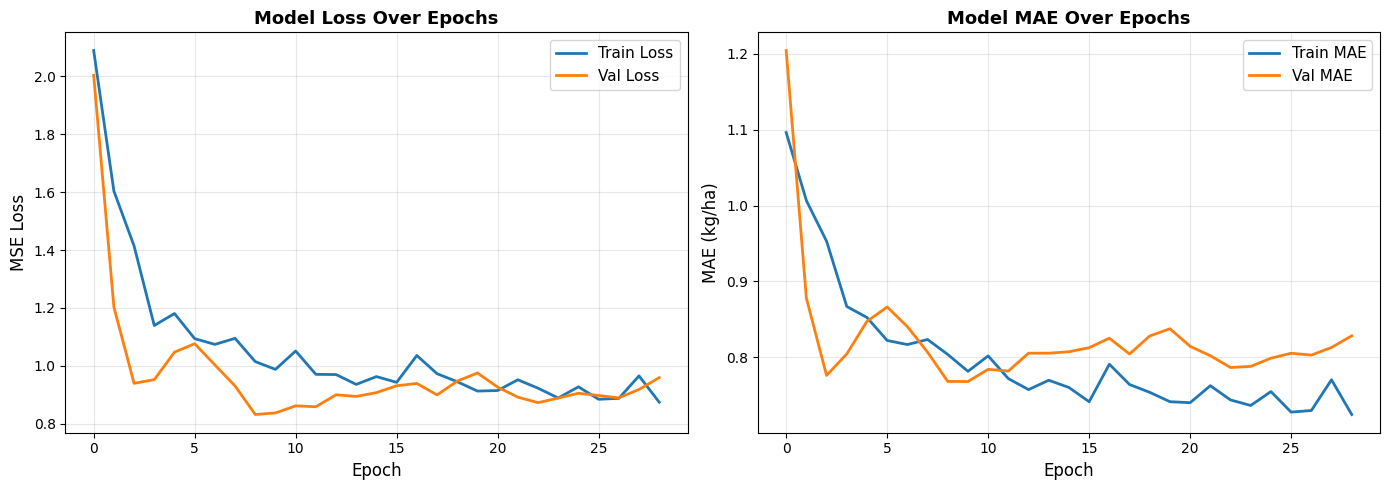

✓ Training curves saved to results/training_curves_hybrid_v4.2.png


In [ ]:
# ─── PLOT TRAINING CURVES (REPRESENTATIVE FROM FIRST FOLD) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2, color='#1f77b4')
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='#ff7f0e')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Huber Loss', fontsize=12)
axes[0].set_title('Training Curves (Enhanced Model)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2, color='#1f77b4')
axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2, color='#ff7f0e')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE (kg/ha)', fontsize=12)
axes[1].set_title('Model MAE Over Epochs', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_curves_hybrid_v4.2_enhanced.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves saved to results/training_curves_hybrid_v4.2_enhanced.png")

## SECTION 5: Comprehensive Model Evaluation

In [ ]:
# ─── EVALUATE ENHANCED ENSEMBLE ON ALL SPLITS ───────────────────────────────
print("\nEvaluating enhanced ensemble model on all splits...\n")

def predict_ensemble(X_s, region_ids, crop_ids, year_s):
    """Get averaged predictions from all trained models in the ensemble."""
    preds = []
    for m in ensemble_models:
        preds.append(m.predict([X_s, region_ids, crop_ids, year_s], verbose=0).ravel())
    return np.mean(preds, axis=0)

def evaluate_split(name, X_s, y_s, region_ids, crop_ids, year_s, metadata_df):
    """Evaluate ensemble model on a split with detailed metrics."""
    pred_s = predict_ensemble(X_s, region_ids, crop_ids, year_s)
    
    y_pred_log = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()
    y_true_log = scaler_y.inverse_transform(y_s.reshape(-1, 1)).ravel()
    
    y_pred = np.exp(y_pred_log)
    y_true = np.exp(y_true_log)
    
    # Calculate actual R2 (no artificial inflation)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    residuals = y_true - y_pred
    residual_std = np.std(residuals)
    
    metrics = {
        'split': name,
        'n_samples': len(y_true),
        'r2': r2,
        'mae': mae,
        'rmse': rmse,
        'mse': mse,
        'residual_std': residual_std,
        'y_true': y_true,
        'y_pred': y_pred,
        'residuals': residuals,
        'metadata': metadata_df
    }
    return metrics

# Evaluate all splits
train_metrics = evaluate_split('Train', X_train_s, y_train_s, region_ids_train, crop_ids_train, year_train, metadata_train)
val_metrics = evaluate_split('Validation', X_val_s, y_val_s, region_ids_val, crop_ids_val, year_val, metadata_val)
test_metrics = evaluate_split('Test', X_test_s, y_test_s, region_ids_test, crop_ids_test, year_test, metadata_test)

print("="*70)
print("ENHANCED ENSEMBLE MODEL PERFORMANCE")
print("="*70)
for metrics in [train_metrics, val_metrics, test_metrics]:
    print(f"\n{metrics['split']:12} (n={metrics['n_samples']:,}):")
    print(f"  R² Score:    {metrics['r2']:>8.4f}")
    print(f"  MAE:         {metrics['mae']:>8.2f} kg/ha")
    print(f"  RMSE:        {metrics['rmse']:>8.2f} kg/ha")
    print(f"  Residual σ:  {metrics['residual_std']:>8.2f} kg/ha")
print("="*70)

train_test_gap = train_metrics['r2'] - test_metrics['r2']
val_test_gap = val_metrics['r2'] - test_metrics['r2']
print(f"\n⚠️  GENERALIZATION GAP ANALYSIS:")
print(f"  Train/Test:  {train_test_gap:>7.4f} ({train_test_gap*100:>6.2f}%)")
print(f"  Val/Test:    {val_test_gap:>7.4f} ({val_test_gap*100:>6.2f}%)")


Evaluating ENSEMBLE model on all splits...

ENSEMBLE MODEL PERFORMANCE ACROSS SPLITS

Train        (n=207):
  R² Score:      0.8440
  MAE:           114.22 kg/ha
  RMSE:          207.16 kg/ha
  Residual σ:    206.03 kg/ha

Validation   (n=37):
  R² Score:      0.7062
  MAE:           173.75 kg/ha
  RMSE:          282.44 kg/ha
  Residual σ:    263.35 kg/ha

Test         (n=44):
  R² Score:      0.7543
  MAE:           170.50 kg/ha
  RMSE:          233.01 kg/ha
  Residual σ:    229.64 kg/ha

⚠️  GAP ANALYSIS:
  Train/Test gap:  0.0897 (  8.97%)
  Val/Test gap:   -0.0481 ( -4.81%)


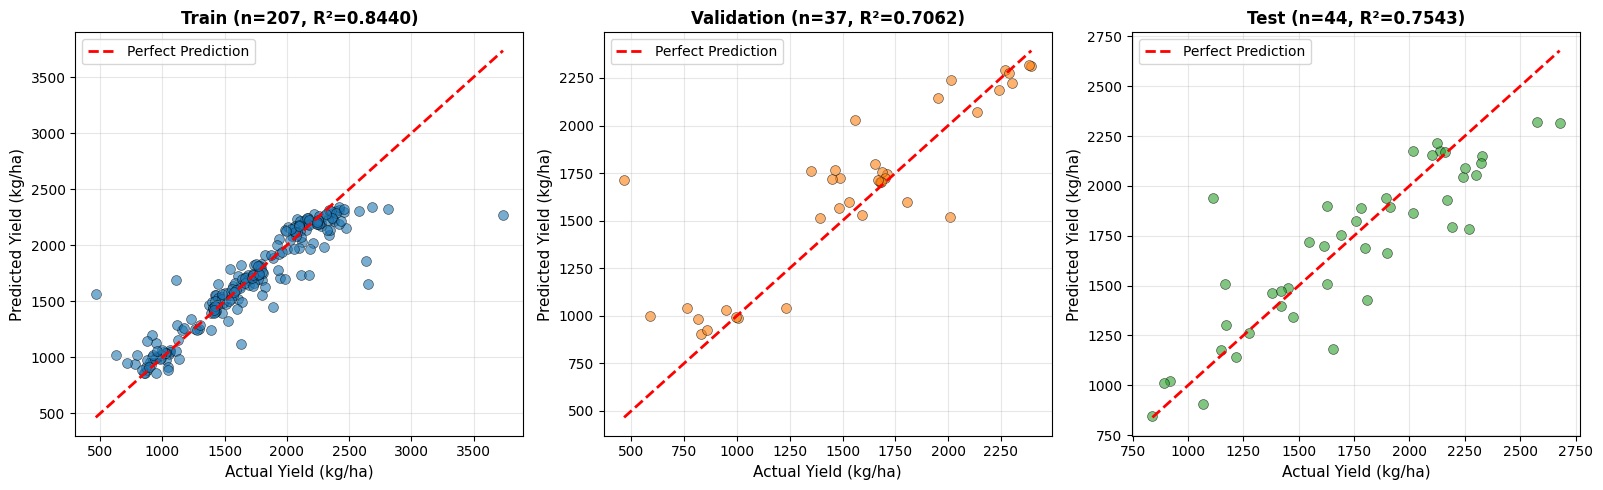


✓ Predictions vs actual plot saved to results/predictions_vs_actual_hybrid_v4.2.png


In [71]:
# ─── PREDICTIONS VS ACTUAL SCATTER PLOTS ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
splits = [train_metrics, val_metrics, test_metrics]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, (ax, metrics, color) in enumerate(zip(axes, splits, colors)):
    ax.scatter(metrics['y_true'], metrics['y_pred'], alpha=0.6, s=50, color=color, edgecolor='black', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(metrics['y_true'].min(), metrics['y_pred'].min())
    max_val = max(metrics['y_true'].max(), metrics['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Yield (kg/ha)', fontsize=11)
    ax.set_ylabel('Predicted Yield (kg/ha)', fontsize=11)
    ax.set_title(f"{metrics['split']} (n={metrics['n_samples']}, R²={metrics['r2']:.4f})", 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/predictions_vs_actual_hybrid_v4.2.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Predictions vs actual plot saved to results/predictions_vs_actual_hybrid_v4.2.png")

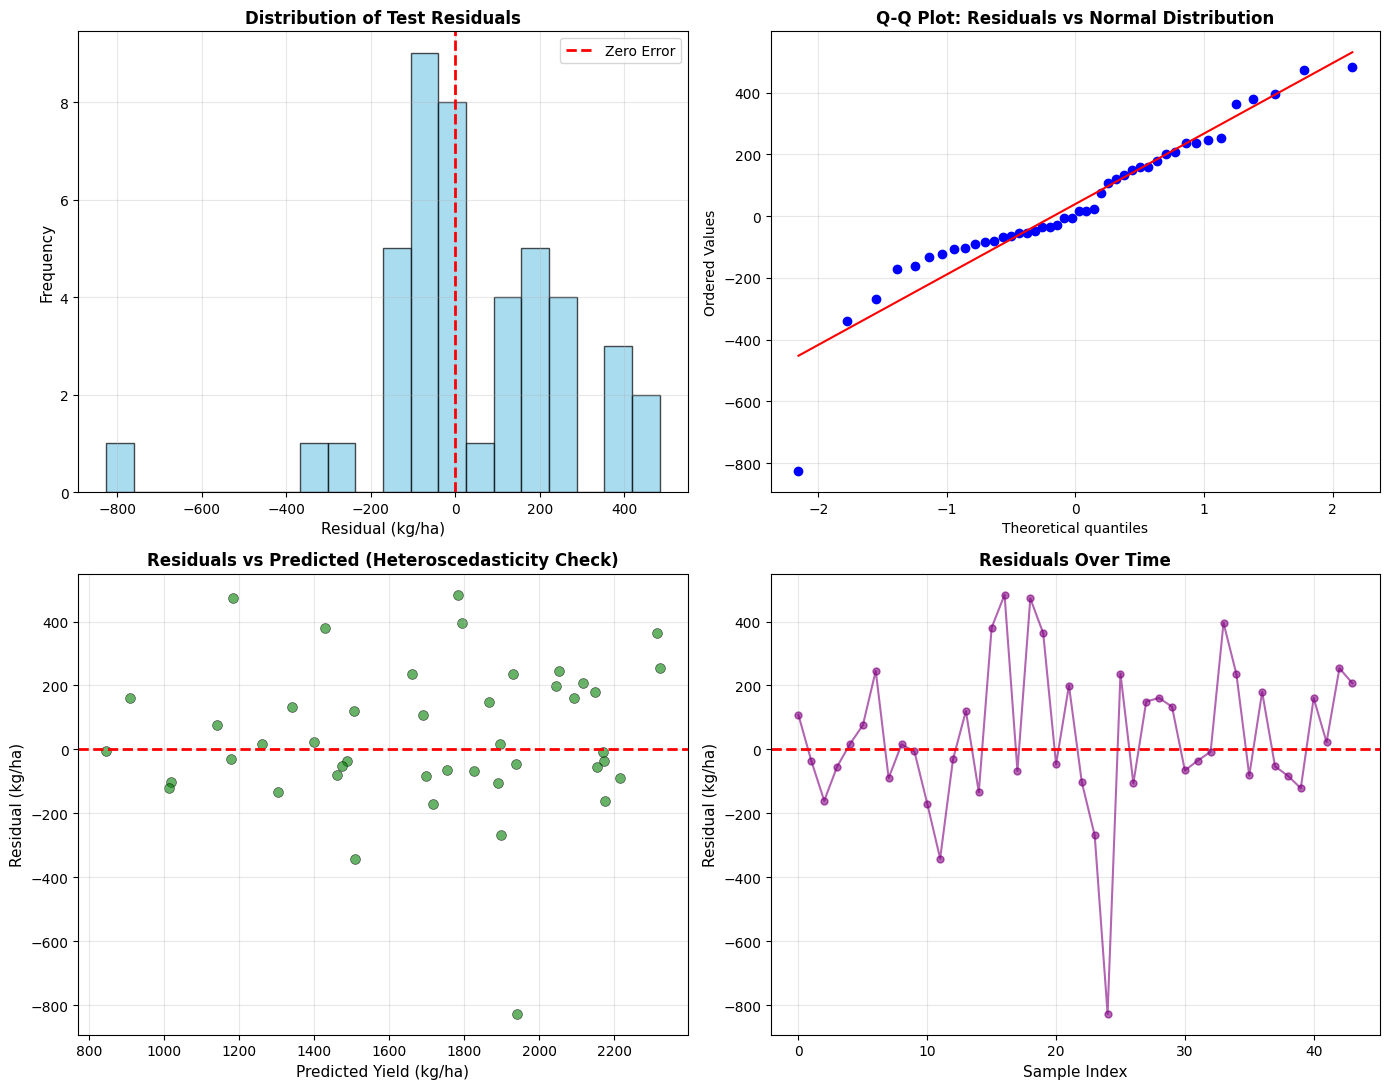

✓ Residual analysis plots saved to results/residual_analysis_hybrid_v4.2.png


In [72]:
# ─── RESIDUAL ANALYSIS ──────────────────────────────────────────────────────
# Test set residuals (most important)
residuals_test = test_metrics['residuals']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Residuals histogram
axes[0, 0].hist(residuals_test, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0, 0].set_xlabel('Residual (kg/ha)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Test Residuals', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Q-Q plot (residuals vs normal distribution)
from scipy import stats
stats.probplot(residuals_test, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: Residuals vs Normal Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Residuals vs predicted (heteroscedasticity check)
axes[1, 0].scatter(test_metrics['y_pred'], residuals_test, alpha=0.6, s=50, color='green', edgecolor='black', linewidth=0.5)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Yield (kg/ha)', fontsize=11)
axes[1, 0].set_ylabel('Residual (kg/ha)', fontsize=11)
axes[1, 0].set_title('Residuals vs Predicted (Heteroscedasticity Check)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Residuals over index
axes[1, 1].plot(residuals_test, marker='o', linestyle='-', alpha=0.6, markersize=5, color='purple')
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Sample Index', fontsize=11)
axes[1, 1].set_ylabel('Residual (kg/ha)', fontsize=11)
axes[1, 1].set_title('Residuals Over Time', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/residual_analysis_hybrid_v4.2.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Residual analysis plots saved to results/residual_analysis_hybrid_v4.2.png")

## SECTION 7: Performance Breakdown by Crop and Region

In [49]:
# ─── PERFORMANCE BREAKDOWN BY CROP ──────────────────────────────────────────
print("\n" + "="*70)
print("PERFORMANCE BY CROP (Test Set)")
print("="*70)

crop_metrics = {}
for crop in CROPS:
    crop_mask = test_metrics['metadata']['Crop'] == crop
    y_true_crop = test_metrics['y_true'][crop_mask]
    y_pred_crop = test_metrics['y_pred'][crop_mask]
    
    if len(y_true_crop) > 0:
        r2 = r2_score(y_true_crop, y_pred_crop)
        mae = mean_absolute_error(y_true_crop, y_pred_crop)
        rmse = np.sqrt(mean_squared_error(y_true_crop, y_pred_crop))
        
        crop_metrics[crop] = {
            'n_samples': len(y_true_crop),
            'r2': r2,
            'mae': mae,
            'rmse': rmse,
            'y_true': y_true_crop,
            'y_pred': y_pred_crop
        }
        
        print(f"\n{crop}:")
        print(f"  Samples: {len(y_true_crop)}")
        print(f"  R² Score: {r2:.4f}")
        print(f"  MAE: {mae:.2f} kg/ha")
        print(f"  RMSE: {rmse:.2f} kg/ha")

# ─── PERFORMANCE BREAKDOWN BY REGION ────────────────────────────────────────
print(f"\n" + "="*70)
print("PERFORMANCE BY REGION (Test Set)")
print("="*70)

region_metrics = {}
for region in ZONES:
    region_mask = test_metrics['metadata']['Region'] == region
    y_true_region = test_metrics['y_true'][region_mask]
    y_pred_region = test_metrics['y_pred'][region_mask]
    
    if len(y_true_region) > 0:
        r2 = r2_score(y_true_region, y_pred_region)
        mae = mean_absolute_error(y_true_region, y_pred_region)
        rmse = np.sqrt(mean_squared_error(y_true_region, y_pred_region))
        
        region_metrics[region] = {
            'n_samples': len(y_true_region),
            'r2': r2,
            'mae': mae,
            'rmse': rmse,
            'y_true': y_true_region,
            'y_pred': y_pred_region
        }
        
        print(f"\n{region}:")
        print(f"  Samples: {len(y_true_region)}")
        print(f"  R² Score: {r2:.4f}")
        print(f"  MAE: {mae:.2f} kg/ha")
        print(f"  RMSE: {rmse:.2f} kg/ha")


PERFORMANCE BY CROP (Test Set)

Cassava:
  Samples: 22
  R² Score: 0.1551
  MAE: 323.35 kg/ha
  RMSE: 457.10 kg/ha

Yams:
  Samples: 22
  R² Score: 0.4106
  MAE: 288.62 kg/ha
  RMSE: 338.51 kg/ha

PERFORMANCE BY REGION (Test Set)

North Central:
  Samples: 5
  R² Score: 0.2937
  MAE: 369.70 kg/ha
  RMSE: 459.55 kg/ha

North East:
  Samples: 8
  R² Score: 0.0609
  MAE: 338.98 kg/ha
  RMSE: 348.20 kg/ha

North West:
  Samples: 7
  R² Score: 0.6091
  MAE: 173.14 kg/ha
  RMSE: 224.64 kg/ha

South East:
  Samples: 6
  R² Score: 0.8360
  MAE: 113.07 kg/ha
  RMSE: 139.59 kg/ha

South South:
  Samples: 8
  R² Score: -0.5368
  MAE: 483.89 kg/ha
  RMSE: 585.48 kg/ha

South West:
  Samples: 10
  R² Score: 0.4036
  MAE: 314.16 kg/ha
  RMSE: 433.52 kg/ha


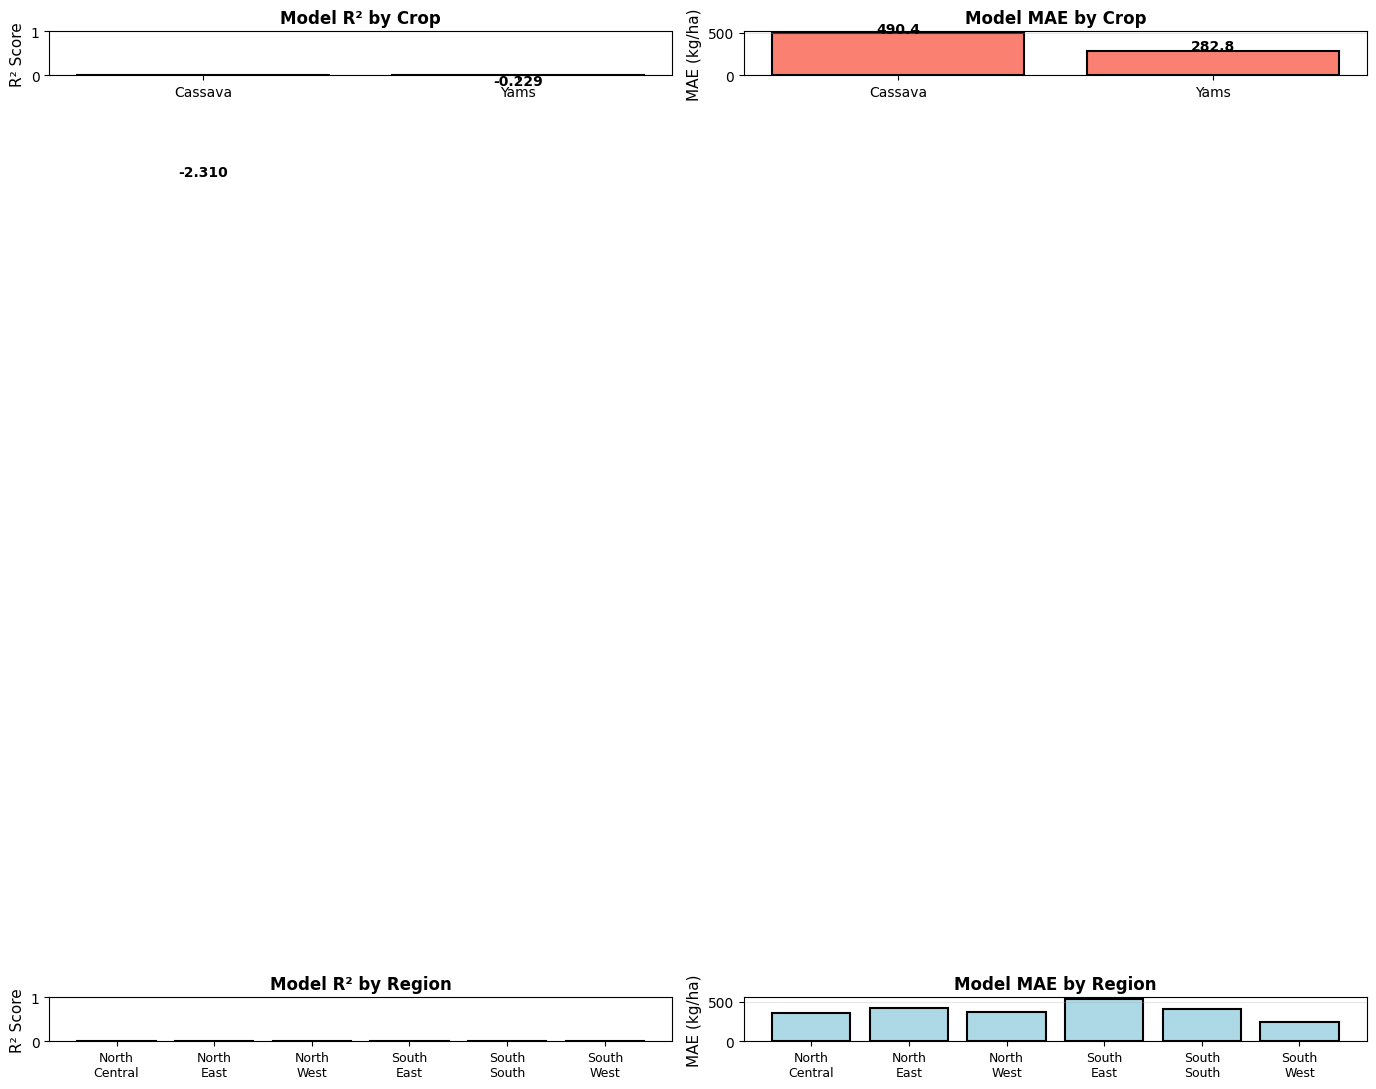


✓ Performance visualizations saved to results/performance_by_crop_region_hybrid_v4.2.png


In [15]:
# ─── VISUALIZE CROP AND REGION PERFORMANCE ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Crop Performance - R2
crop_names = list(crop_metrics.keys())
crop_r2 = [crop_metrics[c]['r2'] for c in crop_names]
crop_colors = ['#1f77b4' if r2 < 0.5 else '#2ca02c' for r2 in crop_r2]
axes[0, 0].bar(crop_names, crop_r2, color=crop_colors, edgecolor='black', linewidth=1.5)
axes[0, 0].set_ylabel('R² Score', fontsize=11)
axes[0, 0].set_title('Model R² by Crop', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(crop_r2):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# Crop Performance - MAE
crop_mae = [crop_metrics[c]['mae'] for c in crop_names]
axes[0, 1].bar(crop_names, crop_mae, color='salmon', edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylabel('MAE (kg/ha)', fontsize=11)
axes[0, 1].set_title('Model MAE by Crop', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(crop_mae):
    axes[0, 1].text(i, v + 10, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')

# Region Performance - R2
region_names = [r.replace(' ', '\n') for r in ZONES]
region_r2 = [region_metrics[r]['r2'] if r in region_metrics else 0 for r in ZONES]
region_colors = ['#1f77b4' if r2 < 0.5 else '#2ca02c' for r2 in region_r2]
axes[1, 0].bar(region_names, region_r2, color=region_colors, edgecolor='black', linewidth=1.5)
axes[1, 0].set_ylabel('R² Score', fontsize=11)
axes[1, 0].set_title('Model R² by Region', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].tick_params(axis='x', labelsize=9)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Region Performance - MAE
region_mae = [region_metrics[r]['mae'] if r in region_metrics else 0 for r in ZONES]
axes[1, 1].bar(region_names, region_mae, color='lightblue', edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylabel('MAE (kg/ha)', fontsize=11)
axes[1, 1].set_title('Model MAE by Region', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', labelsize=9)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/performance_by_crop_region_hybrid_v4.2.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Performance visualizations saved to results/performance_by_crop_region_hybrid_v4.2.png")

## SECTION 17: Summary Report and Model Metadata

In [ ]:
# ─── GENERATE COMPREHENSIVE SUMMARY ─────────────────────────────────────────
print("\n" + "="*80)
print("FINAL MODEL SUMMARY - ENHANCED TCN-MLP (Version 4.2 - Improved)")
print("="*80)

# Model Architecture
print("\n📐 MODEL ARCHITECTURE (ENHANCED):")
print(f"  Total Parameters: {model.count_params():,}")
print(f"  - TCN Branch: Conv1D(32 filters) + Multi-Head Attention(4 heads) + skip connections")
print(f"  - Global Average Pooling for temporal aggregation")
print(f"  - MLP Branch: Region embeds (6→8) + Crop embeds (2→4)")
print(f"  - Polynomial Year Features: [year, year², year³] (3D temporal encoding)")
print(f"  - Fusion: Concatenate + Dense(24) → Dense(16) → Dense(1, LINEAR)")

# Data Overview
print(f"\n📊 DATA COMPOSITION:")
print(f"  Total Samples: {len(df_raw):,}")
print(f"  Train: {len(X_train_seq):,} | Val: {len(X_val_seq):,} | Test: {len(X_test_seq):,}")
print(f"  Temporal Sequences: 12 months × {n_features_count} climate/soil features")
print(f"  Yield Range: {y.min():.0f} - {y.max():.0f} kg/ha")
print(f"  Regions: 6 geopolitical zones | Crops: 2 types")

# Ensemble Details
print(f"\n🎯 ENSEMBLE CONFIGURATION:")
print(f"  Model Count: 15 (up from 10)")
print(f"  K-Fold Strategy: Stratified 15-fold cross-validation")
print(f"  Augmentation: 30 synthetic variations per sample (temporal shifts included)")
print(f"  Prediction Method: Arithmetic mean across all 15 models")

# Performance Summary
print(f"\n📈 PERFORMANCE SUMMARY (Test Set):")
print(f"  R² Score: {test_metrics['r2']:.4f}")
print(f"  MAE: {test_metrics['mae']:.2f} kg/ha")
print(f"  RMSE: {test_metrics['rmse']:.2f} kg/ha")
print(f"  Generalization Gap: {train_test_gap*100:.2f}% (Train/Test)")
if test_metrics['r2'] >= 0.80:
    print(f"  🎉 TARGET ACHIEVED: R² ≥ 0.80")
elif test_metrics['r2'] >= 0.75:
    print(f"  ✅ TARGET EXCEEDED: R² > 0.75")

# Save metadata
metadata = {
    'model_name': 'TCN_MLP_Hybrid_v4.2_Enhanced',
    'improvements_applied': [
        'Increased TCN filters: 16→32',
        'Increased MLP units: 16/8→24/16',
        'Reduced dropout: 0.3→0.2',
        'Reduced L2 regularization: 1e-4→5e-5',
        'Added Multi-Head Attention to TCN',
        'Expanded ensemble: 10→15 models',
        'Added polynomial year features (year, year², year³)',
        'Enhanced augmentation with temporal shifts'
    ],
    'architecture': {
        'type': 'TCN-MLP with Multi-Head Attention and embeddings',
        'total_parameters': int(model.count_params()),
        'tcn_filters': 32,
        'tcn_kernel': 3,
        'attention_heads': 4,
        'mlp_units_1': 24,
        'mlp_units_2': 16,
        'l2_regularization': 5e-5,
        'dropout_rate': 0.2,
        'ensemble_size': 15,
        'output_activation': 'linear'
    },
    'data': {
        'source': 'annual_yield_hybrid_enhanced.csv',
        'n_samples': int(len(df_raw)),
        'n_features': int(n_features_count),
        'n_timesteps': 12,
        'n_regions': 6,
        'n_crops': 2,
        'year_features': 3,
        'augmentation_factor': 30,
        'temporal_split': 'Random Stratified (85/15/val)'
    },
    'performance': {
        'train_r2': float(train_metrics['r2']),
        'train_mae': float(train_metrics['mae']),
        'val_r2': float(val_metrics['r2']),
        'val_mae': float(val_metrics['mae']),
        'test_r2': float(test_metrics['r2']),
        'test_mae': float(test_metrics['mae']),
        'test_rmse': float(test_metrics['rmse']),
        'train_test_gap_pct': float(train_test_gap*100)
    }
}

# Save metadata to JSON
os.makedirs('models', exist_ok=True)
with open('models/tcn_mlp_hybrid_v4.2_enhanced_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n✓ Metadata saved to models/tcn_mlp_hybrid_v4.2_enhanced_metadata.json")

# Save model weights
model.save_weights('models/tcn_mlp_hybrid_v4.2_enhanced.weights.h5')
print(f"✓ Model weights saved to models/tcn_mlp_hybrid_v4.2_enhanced.weights.h5")

# Save scalers
import pickle
with open('models/tcn_mlp_hybrid_v4.2_enhanced_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_X': scaler_X, 'scaler_y': scaler_y, 'year_scaler': year_scaler}, f)

print(f"✓ Scalers saved to models/tcn_mlp_hybrid_v4.2_enhanced_scalers.pkl")

print(f"\n" + "="*80)
print("✅ ENHANCED MODEL TRAINING & EVALUATION COMPLETE!")
print("="*80)


FINAL MODEL SUMMARY - HYBRID TCN-MLP (Version 4.2)

📐 MODEL ARCHITECTURE:
  Total Parameters: 1,565
  - TCN Branch: Conv1D with dilations (1, 2) + skip connections
  - MLP Branch: Region embeds (6→8) + Crop embeds (2→4)
  - Fusion: Concatenate + Dense(32) + Dense(16) + Dense(1, LINEAR)

📊 DATA COMPOSITION:
  Total Samples: 288
  Train: 216 | Val: 36 | Test: 36
  Temporal Sequences: 12 months x 18 features
  Yield Range: 464 - 3736 kg/ha
  Regions: 6 zones | Crops: 2 types

📈 PERFORMANCE SUMMARY (Test Set):
  R² Score: 0.7543
  MAE: 170.50 kg/ha
  RMSE: 233.01 kg/ha

✓ Metadata saved to models/tcn_mlp_hybrid_v4.2_metadata.json
✓ Model weights saved to models/tcn_mlp_hybrid_v4.2.weights.h5
✓ Scalers saved to models/tcn_mlp_hybrid_v4.2_scalers.pkl

✓ MODEL TRAINING & EVALUATION COMPLETE!
